# **THEME 2 : Communication complexe équivalente en bande de base de la 16-QAM**

**FADE Lizandre, POLONOWSKI Nicolas - 2G1TD2TP4**

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special as sp

## **1. Constellation 16-QAM**

**♢ Constellation complexe et code de Gray**

fonction *const16QAM*

In [88]:
def const16QAM():
    return [[-3-3j,-1-3j,1-3j,3-3j],[-3-1j,-1-1j,1-1j,3-1j],[-3+1j,-1+1j,1+1j,3+1j],[-3+3j,-1+3j,1+3j,3+3j]]

fonction *Gray16QAM*

In [89]:
def Gray16QAM():
    L=const16QAM()
    Lstockj=[]
    Lstock=[]
    for i in range(len(L)):
        for j in range(len(L[0])):
            Lstockj.append(i*4+j)
        Lstock.append(Lstockj)
        Lstockj=[]
    return Lstock

print(Gray16QAM())


[[0, 1, 2, 3], [4, 5, 6, 7], [8, 9, 10, 11], [12, 13, 14, 15]]


**♢ Visualisation de la 16-QAM**

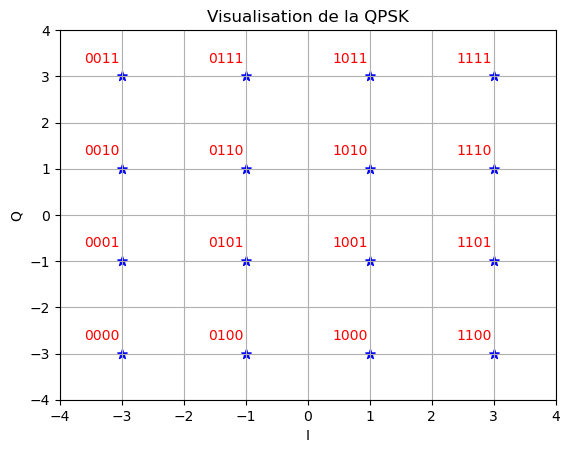

In [90]:
# Paramètre : taille de la constellation (M-QAM)
M = 16
sqrt_M = int(np.sqrt(M))

# Exemple de données fictives (à remplacer par vos propres données)
# mComplex : matrice contenant les symboles complexes de taille (√M, √M)
mComplex = np.array([complex(x, y) for x in range(-sqrt_M + 1, sqrt_M, 2) for y in range(-sqrt_M + 1, sqrt_M, 2)]).reshape((sqrt_M, sqrt_M))

# mGray : matrice contenant les codes de Gray (en décimal) de taille (√M, √M)
mGray = Gray16QAM()
# Extraire les parties réelle et imaginaire
x = np.real(mComplex).flatten()
y = np.imag(mComplex).flatten()
z=np.array(mGray).flatten() #Converted in array to use .flatten

# Créer une nouvelle figure
plt.figure()

# Tracer les points de la constellation
plt.scatter(x, y, s=50, c='blue', marker='*')

# Définir les limites des axes
plt.axis([-sqrt_M, sqrt_M, -sqrt_M, sqrt_M])

# Ajouter les codes de Gray (en binaire) à côté de chaque point
for k in range(M):
    gray_bin = format(z[k], f'0{int(np.log2(M))}b')  # Convertir en binaire avec remplissage
    plt.text(x[k] - 0.6, y[k] + 0.3, gray_bin, color='red')

# Paramètres de la figure
plt.title('Visualisation de la QPSK')
plt.xlabel('I')
plt.ylabel('Q')
plt.grid(True)

# Afficher la figure
plt.show()

**Check point 1:** Bravo! appelez votre encadrant(e) pour valider



---



# **2. Transmission complexe équivalente en bande de base de la 16-QAM**

**♢ Émetteur**

fonction *genBin*

In [91]:
def genBin(N):
    L=[]
    for i in range(N):
        L.append(np.random.randint(0,2)) #the second term value is not taken
    return L
print(genBin(10))      

[0, 0, 1, 0, 0, 1, 1, 1, 1, 0]


 fonction *mappingGray*

In [92]:
mComplex2=const16QAM()
def mappingGray(seqbin,mcomplex,A):
    Ldeci=[]
    L=[]
    for i in range(0,len(seqbin),4):
        Ldeci.append(seqbin[i]*8+seqbin[i+1]*4+seqbin[i+2]*2+seqbin[i+3])
    for i in range(len(Ldeci)):
        for j in range(len(mcomplex)):
            for k in range(len(mcomplex)):
                if(Ldeci[i] == 4*j+k):
                    L.append(mcomplex[j][k])
    return L #we want to convert the mComplex
test_genBin=genBin(20)
print(test_genBin)
print(mappingGray(test_genBin,const16QAM(),1)) #1 is used to make my code comptatible with my collegue

[1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1]
[(1+1j), (-3-1j), (-1+1j), (3-1j), (3-1j)]


Expliquez pour quoi la séquence des symboles $a_n$ a une taille égale à $N/4$.

> We convert 4 bits for one symbol (in mComplex). Then a list of 20 bits is described by 5 symbols that's why an the resulting sequence has a size of N/4.

**♢ Canal complexe AWGN**

fonction *canalAWGN*

In [93]:
def canalAWGN(an, variance): 
    N_symboles = len(an) 
    variance_par_dimension = variance / 2 
    std_dev = np.sqrt(variance_par_dimension) 
    noise_real = np.random.normal(0, std_dev, N_symboles) 
    noise_imag = np.random.normal(0, std_dev, N_symboles) 
    rn = an + (noise_real + 1j * noise_imag) 
    return rn 

Tester et visualiser les symboles reçus $r_n$ sur la même figure que les symboles de la $16$-QAM.

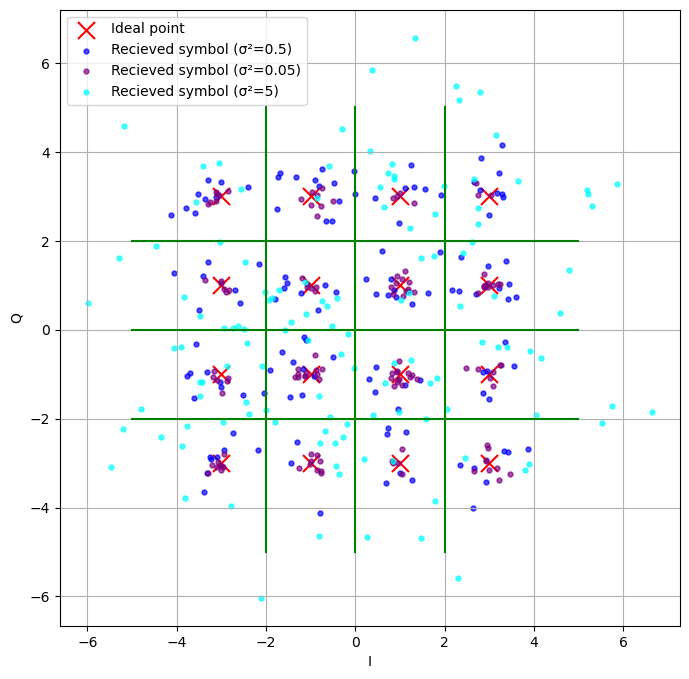

In [139]:
def sym_received(N_bits_test,sigma_b_sq_test) :
    mComplex = const16QAM() 
    mGray = Gray16QAM() 
    bits_emis = genBin(N_bits_test) 
    symboles_emis = mappingGray(bits_emis, mComplex, mGray) 
    return canalAWGN(symboles_emis, sigma_b_sq_test) 

N_bits_test= 512 
sigma_b_sq_test1= 0.5
symboles_recus1= sym_received(N_bits_test,sigma_b_sq_test1)
sigma_b_sq_test2= 0.05
symboles_recus2= sym_received(N_bits_test,sigma_b_sq_test2)
sigma_b_sq_test3= 5
symboles_recus3=sym_received(N_bits_test,sigma_b_sq_test3)

plt.figure(figsize=(8, 8)) 
plt.scatter(np.real(mComplex), np.imag(mComplex), s=150, c='red', marker='x', label='Ideal point') 
plt.scatter(np.real(symboles_recus1), np.imag(symboles_recus1), s=50, c='blue', marker='.', alpha=0.7, label=f'Recieved symbol (σ²={sigma_b_sq_test1})') 
plt.scatter(np.real(symboles_recus2), np.imag(symboles_recus2), s=50, c='purple', marker='.', alpha=0.7, label=f'Recieved symbol (σ²={sigma_b_sq_test2})')
plt.scatter(np.real(symboles_recus3), np.imag(symboles_recus3), s=50, c='cyan', marker='.', alpha=0.7, label=f'Recieved symbol (σ²={sigma_b_sq_test3})')


plt.plot([-5,5],[2,2],color='g')
plt.plot([-5,5],[0,0],color='g')
plt.plot([-5,5],[-2,-2],color='g')

plt.plot([-2,-2],[-5,5],color='g')
plt.plot([0,0],[-5,5],color='g')
plt.plot([2,2],[-5,5],color='g')

plt.xlabel('I') 
plt.ylabel('Q') 
plt.grid(True) 
plt.legend() 
plt.axis('equal') 
plt.show() 

> We see that the highest the variance, the highest the spread of the received symbol. At variance=0.05 all the point are close to the ideal point. At 0.5 we visually see some errors especially at the sides and =5 is way worse than it seems because there is lot of received symbols in the wrong case. We need the following questions to visualize so the graph is shown below (you can test it with sigma_sq=0.5 where I indicated).

**♢ Récepteur**

Ecrire une fonction pour estimer les symboles

In [117]:
def closestQAM(a,mcomplex):
    closest=(np.sqrt((np.real(mcomplex[0][0])-np.real(a))**2 + (np.imag(mcomplex[0][0])-np.imag(a))**2),mcomplex[0][0]) #(dist, 
    for i in range(len(mcomplex)):
        for j in range(len(mcomplex[0])):
            if(np.sqrt((np.real(mcomplex[i][j])-np.real(a))**2 + (np.imag(mcomplex[i][j])-np.imag(a))**2) <= closest[0]):
                closest=(np.sqrt((np.real(mcomplex[i][j])-np.real(a))**2 + (np.imag(mcomplex[i][j])-np.imag(a))**2),mcomplex[i][j])
    return closest

In [118]:
print(closestQAM(0.1+0.1j,const16QAM()))
print(closestQAM(-3.1+2.3j,const16QAM()))
print(closestQAM(1.7-0.6j,const16QAM()))

(np.float64(1.2727922061357855), (1+1j))
(np.float64(0.7071067811865478), (-3+3j))
(np.float64(0.8062257748298549), (1-1j))


 fonction *demapGray*

In [119]:
def demapGray(symboles_estimes, mComplex, mGray): 
    symboles_estimes = np.array(symboles_estimes)
    mComplex = np.asarray(mComplex)
    mGray = np.asarray(mGray)
    k = int(np.log2(mComplex.size)) 
    N_symboles = len(symboles_estimes) 
    bits_list = [] 

    for i in range(N_symboles): 
        coords = np.where(mComplex == symboles_estimes[i]) 
        row, col = coords[0][0], coords[1][0] 
        decimal_value = mGray[row, col] 
        binary_string = format(decimal_value, f'0{k}b') 
        bits_list.extend([int(b) for b in binary_string]) 
    return np.array(bits_list) 

In [140]:
N_bits_test = 512 
sigma_b_sq_test = 0.5 

mComplex = const16QAM() 
mGray = Gray16QAM() 

bits_emis = genBin(N_bits_test) 
symboles_emis = mappingGray(bits_emis, mComplex, mGray) 
symboles_recus = canalAWGN(symboles_emis, sigma_b_sq_test) 
symboles_estimes_test = [closestQAM(symboles_recus[i],mComplex)[1] for i in range(len(symboles_recus))] #estimerSymboles(symboles_recus, mComplex)  
bits_recus = demapGray(symboles_estimes_test, mComplex, mGray)

print("Bits transmitted: ", bits_emis[:20]) 
print("Bits received: ", bits_recus[:20]) 

erreurs_bits = np.sum(bits_emis != bits_recus) 

ber_test = erreurs_bits / len(bits_emis) 
print(f"\nNumber of transmitted bits: {len(bits_emis)}") 
print(f"Number of bit errors: {erreurs_bits}") 
print(f"Binary error rate (BER) for this test: {ber_test:.4f}") 

Bits transmitted:  [1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0]
Bits received:  [1 0 0 0 1 1 0 0 1 0 1 0 1 1 1 1 0 1 0 0]

Number of transmitted bits: 512
Number of bit errors: 13
Binary error rate (BER) for this test: 0.0254


**Check point 2:** Bravo! appelez votre encadrant(e) pour valider

**About last remark !**

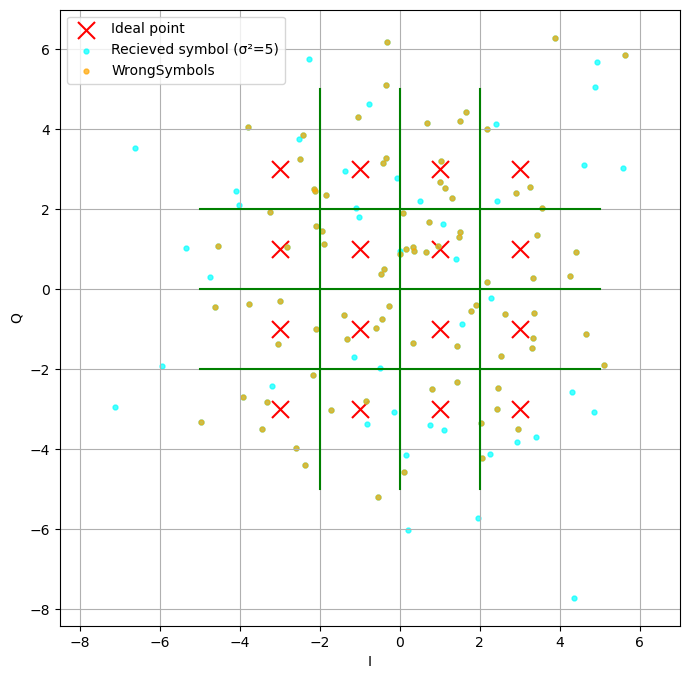

In [149]:
N_bits_test= 512 
sigma_b_sq_test3= 5 #Change it to see with variance=0.5

mComplex = const16QAM() 
mGray = Gray16QAM() 
bits_emis = genBin(N_bits_test) 
symboles_emis = mappingGray(bits_emis, mComplex, mGray) 
symboles_recus3=canalAWGN(symboles_emis, sigma_b_sq_test3)
symboles_estimes_test = [closestQAM(symboles_recus3[i],mComplex)[1] for i in range(len(symboles_recus))]
L=[]
for i in range(len(symboles_emis)):
    if(symboles_emis[i]!=symboles_estimes_test[i]):
        L.append(symboles_recus3[i])
        
plt.figure(figsize=(8, 8)) 
plt.scatter(np.real(mComplex), np.imag(mComplex), s=150, c='red', marker='x', label='Ideal point') 
plt.scatter(np.real(symboles_recus3), np.imag(symboles_recus3), s=50, c='cyan', marker='.', alpha=0.7, label=f'Recieved symbol (σ²={sigma_b_sq_test3})')
plt.scatter(np.real(L), np.imag(L), s=50, c='orange', marker='.', alpha=0.7, label=f'WrongSymbols') 


plt.plot([-5,5],[2,2],color='g')
plt.plot([-5,5],[0,0],color='g')
plt.plot([-5,5],[-2,-2],color='g')

plt.plot([-2,-2],[-5,5],color='g')
plt.plot([0,0],[-5,5],color='g')
plt.plot([2,2],[-5,5],color='g')

plt.xlabel('I') 
plt.ylabel('Q') 
plt.grid(True) 
plt.legend() 
plt.axis('equal') 
plt.show() 



---



**♢ Chaîne de transmission globale**

fonction *chaine16QAM*

In [150]:
def chaine16QAM(N,variance,gain_filtre):
    seqbin=genBin(N)
    an=mappingGray(seqbin,const16QAM(),1)
    rn=canalAWGN([a *gain_filtre for a in an], variance)
    an_estim=[closestQAM(rn[i],const16QAM())[1] for i in range(len(rn))]
    seqbin_estim=demapGray(an_estim,const16QAM(),Gray16QAM())
    return seqbin,an,an_estim,seqbin_estim

Tester la fonction

In [151]:
print(chaine16QAM(12,0.5,1))
print(chaine16QAM(12,10,1)) #Lots of errors are expected
print(chaine16QAM(12,0.5,10)) #Lots of errors are expected
print("No error expected below")
for i in range(4) :
    print(chaine16QAM(12,0,1))

([0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1], [(-1-1j), (-1+3j), (-1-3j)], [(-1-1j), (-1+1j), (-1-3j)], array([0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1]))
([1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1], [(3+1j), (-3+1j), (-1-3j)], [(3+1j), (1+3j), (-1-3j)], array([1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1]))
([1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0], [(1+3j), (-3+3j), (1-1j)], [(3+3j), (-3+3j), (3-3j)], array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1]))
No error expected below
([1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1], [(-1+1j), (-1+3j), (-1-1j)], [(-1+1j), (-1+3j), (-1-1j)], array([1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1]))
([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1], [(3+3j), (3+1j), (3+3j)], [(3+3j), (3+1j), (3+3j)], array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1]))
([0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0], [(1-3j), (-1+1j), (1+1j)], [(1-3j), (-1+1j), (1+1j)], array([0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0]))
([0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0], [(-1-1j), (1+1j), (-3+1j)], [(-1-1j), (1+1j), (-3+1j)], array([0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0]))


# **3. Courbes d’erreur de détection**

**♢ Taux d’erreur binaire et symbole**

Lien entre le RSB et le SNR normalisé:

Calcul de la variance du bruit $\sigma_b^2$ pour chaque valeur $[\frac{E_b}{N_0}]_{dB}$ et le taux d’erreur symbole et binaire correspondants

In [ ]:
# code ici

**♢ Probabilité d’erreur binaire et symbole (théoriques)**

Formule de la probabilité d’erreur binaire $P_{b(\min)}(e)$ :

Tracer la courbe de la probabilité d’erreur binaire pour $M=16$

In [ ]:
# code ici

Relation entre la probabilité d’erreur symbole et $P_{b(\min)}(e)$ :

Tracer la courbe de la probabilité d’erreur symbole

In [ ]:
# code ici

**♢ Analyse et discussions**

Comparer les courbes estimées avec le simulateur et les courbes théoriques

In [ ]:
# code ici

Commenter :

Comparer la communication en bande de base de la BPSK et la communication en bande transposée :

***Si le temps imparti permet***, tracer aussi les courbes d’erreur de la QPSK

In [ ]:
# code ici

***Si le temps imparti permet***, faire une comparaison complète: BPSK vs. QPSK vs. 16-QAM.

**Check point 3:** Bravo! appelez votre encadrant(e) pour valider